# Section 2: Data Analysis

INSTK5000/9000 Project 1, student housing allocation.

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.tools.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor

from constants import *
from preprocessing import detect_grade_format, standardize_grades

import warnings
warnings.filterwarnings("ignore")

set_project_theme()
pd.set_option("display.width", 120)
%matplotlib inline

## 1. Loading the data

In [3]:
house_df = pd.read_csv(DATA_PATH)
print('Number of rows:', house_df.shape[0])
print('Number of columns:', house_df.shape[1])

Number of rows: 2500
Number of columns: 13


In [4]:
house_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   international           2500 non-null   object 
 1   age                     2500 non-null   int64  
 2   semesters_completed     2500 non-null   int64  
 3   commute_distance_km     2500 non-null   float64
 4   financial_need_score    2500 non-null   float64
 5   housing_urgency_rating  2500 non-null   float64
 6   grades                  2375 non-null   object 
 7   should_recieve_housing  2500 non-null   int64  
 8   HO                      2500 non-null   int64  
 9   A1                      2500 non-null   int64  
 10  A2                      2500 non-null   int64  
 11  A3                      2500 non-null   int64  
 12  A4                      2500 non-null   int64  
dtypes: float64(3), int64(8), object(2)
memory usage: 254.0+ KB


In [5]:
house_df.head()

,international,age,semesters_completed,commute_distance_km,financial_need_score,housing_urgency_rating,grades,should_recieve_housing,HO,A1,A2,A3,A4
0,domestic,26,2,31.1,62.93,5.8,4.34,1,1,0,1,0,0
1,domestic,27,5,13.2,66.45,5.9,4.83,1,1,0,1,1,0
2,domestic,25,5,9.8,50.23,5.2,NaN,1,0,0,0,0,0
3,domestic,21,2,20.2,56.99,5.7,2.06,1,1,0,0,1,0
4,domestic,34,7,51.9,32.31,4.6,4.24,0,0,0,0,0,0


In [6]:
house_df.describe(include='all')

,international,age,semesters_completed,commute_distance_km,financial_need_score,housing_urgency_rating,grades,should_recieve_housing,HO,A1,A2,A3,A4
count,2500,2500.000000,2500.00000,2500.000000,2500.000000,2500.000000,2375,2500.000000,2500.000000,2500.000000,2500.0000,2500.000000,2500.000000
unique,2,NaN,NaN,NaN,NaN,NaN,592,NaN,NaN,NaN,NaN,NaN,NaN
top,domestic,NaN,NaN,NaN,NaN,NaN,B,NaN,NaN,NaN,NaN,NaN,NaN
freq,1907,NaN,NaN,NaN,NaN,NaN,43,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,25.804400,5.33760,20.139400,56.019732,4.950560,NaN,0.350000,0.370000,0.264800,0.3976,0.292000,0.260800
std,NaN,4.229479,2.79606,14.385467,16.646085,1.692314,NaN,0.477065,0.482901,0.441315,0.4895,0.454773,0.439159
min,NaN,19.000000,0.00000,0.000000,8.670000,0.500000,NaN,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000
25%,NaN,22.000000,3.00000,8.400000,43.875000,3.700000,NaN,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000
50%,NaN,25.000000,5.00000,17.650000,56.785000,5.000000,NaN,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000
75%,NaN,29.000000,7.00000,29.300000,68.130000,6.200000,NaN,1.000000,1.000000,1.000000,1.0000,1.000000,1.000000


### Feature types

We have 2500 applications and 13 columns. Seven of them are recorded features about the applicant, one is the
target, and five are the decisions (the housing officer and the four algorithms).

| Feature | Type |
|---|---|
| international | categorical, nominal, binary (domestic / international) |
| age | numerical, discrete (19 to 39) |
| semesters_completed | numerical, discrete and ordinal (0 to 12) |
| commute_distance_km | numerical, continuous |
| financial_need_score | numerical, continuous (0 to 100) |
| housing_urgency_rating | numerical, continuous (0 to 10) |
| grades | mixed, stored as text, needs cleaning before we can call it numerical |
| should_recieve_housing | categorical, nominal, binary (our target) |
| HO, A1, A2, A3, A4 | categorical, nominal, binary (the decisions) |

Two things are already visible from `info()`. First, `grades` is read as text and not as a number, so something
is wrong with it. Second, `grades` is the only column with missing values.

## 2. Tidying the data

In [7]:
missing_features = [bool(pd.notna(house_df[col]).all()) for col in house_df.columns]
list(zip(house_df.columns, missing_features))

[('international', True),
 ('age', True),
 ('semesters_completed', True),
 ('commute_distance_km', True),
 ('financial_need_score', True),
 ('housing_urgency_rating', True),
 ('grades', False),
 ('should_recieve_housing', True),
 ('HO', True),
 ('A1', True),
 ('A2', True),
 ('A3', True),
 ('A4', True)]

### As you can see we are struggling with missing values just in grades

In [8]:
sample_size = len(house_df)
missing_count = house_df.grades.isna().sum()
print('Total number of samples:', sample_size)
print('Number of missing values:', missing_count)
print('Ratio of missing values:', round(missing_count / sample_size, 3))

Total number of samples: 2500
Number of missing values: 125
Ratio of missing values: 0.05


In [9]:
house_df['grades_raw'] = house_df.grades

### The grades column mixes several formats

Before imputing anything, we should look at what is actually inside this column. The values are not all on the
same scale, we have letters (A to F), values that look like a 0 to 10 scale, and values that look like a 0 to 100
scale. Let us label each row with the format it uses and see how these formats are distributed. We label the rows
using only the value itself, never the student's group, because using the sensitive feature to clean the data
would put it straight back into the cleaned column.

In [10]:
house_df['grade_format'] = detect_grade_format(house_df.grades)

print(house_df.grade_format.value_counts(), '\n')
print('Counts by group:')
print(pd.crosstab(house_df.grade_format, house_df.international))
print('\nShare inside each group:')
print(pd.crosstab(house_df.grade_format, house_df.international, normalize='columns').round(3))

grade_format
numeric_0_10     2093
numeric_0_100     167
missing           125
letter            115
Name: count, dtype: int64 

Counts by group:
international  domestic  international
grade_format                          
letter                0            115
missing              95             30
numeric_0_10       1812            281
numeric_0_100         0            167

Share inside each group:
international  domestic  international
grade_format                          
letter             0.00          0.194
missing            0.05          0.051
numeric_0_10       0.95          0.474
numeric_0_100      0.00          0.282


### This is the most important finding of the tidying part

The format of the grade is not random at all. Every domestic student is recorded on the numeric 0 to 10 format,
and the letter grades and the 0 to 100 format appear only among international students. So the grade format alone
tells you with certainty whether a student is international, unless the student is in the 0 to 10 group.

This means `grades` is not only a weak feature, it also carries the sensitive attribute inside it. Even if the
university removed the `international` column, an algorithm using raw grades could still separate the two groups.
This is the proxy problem we come back to in the data hazards section.

### The 0 to 10 group is really two different scales

The obvious conversion is to multiply the 0 to 10 values by 10 and read the letters as band midpoints. Before we
do that, we should check whether the 0 to 10 group is one scale at all.

In [11]:
numeric_grades = pd.to_numeric(house_df.grades_raw, errors='coerce')
low_scale = numeric_grades[house_df.grade_format == 'numeric_0_10']

print('0 to 10 group, domestic students:')
print(low_scale[house_df.international == 'domestic'].describe().round(2), '\n')

print('0 to 10 group, international students:')
print(low_scale[house_df.international == 'international'].describe().round(2), '\n')

print('domestic values above 6:', int((low_scale[house_df.international == 'domestic'] > 6).sum()))
print('international values above 6:', int((low_scale[house_df.international == 'international'] > 6).sum()))

0 to 10 group, domestic students:
count    1812.00
mean        4.34
std         1.00
min         1.34
25%         3.65
50%         4.47
75%         5.16
max         5.99
Name: grades_raw, dtype: float64 

0 to 10 group, international students:
count    281.00
mean       4.73
std        2.34
min        1.10
25%        2.90
50%        4.40
75%        6.20
max        9.90
Name: grades_raw, dtype: float64 

domestic values above 6: 0
international values above 6: 74


The domestic values stop dead at 5.99 and not one of them reaches 6, so this is a 1 to 6 scale. The international
values in the same group run up to 9.9, with 74 of them above 6, so those are on a 1 to 10 scale. The two are
mixed together in one column and there is no way to tell, for a single value like 4.2, which scale it came from.

So the 0 to 10 group hides a fourth format, and any rule that multiplies the whole group by the same number is
wrong for one part of it.

### Comparing three possible conversions

`grades` should not carry information about where a student comes from, because the value is supposed to say
something about the student and not about the office that typed it in. That gives us a way to compare the
candidate conversions: the one that is right should leave almost no correlation between `grades` and
`international`, since the correlation we see now is produced by the recording format and not by the students.

1. multiply the 0 to 10 values by 10, letters to band midpoints (the obvious rule)
2. rescale each scale by its own maximum, so the 1 to 6 values are divided by 6 and the 1 to 10 values by 10
3. replace the grade by the student's percentile inside their own recording format

In [12]:
letter_midpoints = {'A': 90, 'B': 80, 'C': 70, 'D': 60, 'F': 50}
letters = house_df.grades_raw.map(lambda v: letter_midpoints.get(str(v).strip().upper(), np.nan))
is_domestic_scale = (house_df.grade_format == 'numeric_0_10') & (house_df.international == 'domestic')

times_ten = np.where(numeric_grades.isna(), letters,
                     np.where(numeric_grades > 10, numeric_grades, numeric_grades * 10))

by_maximum = np.select(
    [is_domestic_scale, house_df.grade_format == 'numeric_0_10',
     house_df.grade_format == 'numeric_0_100', house_df.grade_format == 'letter'],
    [numeric_grades / 6 * 100, numeric_grades / 10 * 100, numeric_grades, letters],
    default=np.nan
)

by_percentile, _ = standardize_grades(house_df.grades_raw)

candidates = {'multiply by ten': pd.Series(times_ten, index=house_df.index),
              'rescale by maximum': pd.Series(by_maximum, index=house_df.index),
              'percentile in format': by_percentile}

rows = []
for name, values in candidates.items():
    values = values.fillna(values.mean())
    rows.append({
        'conversion': name,
        'r with international': stats.pointbiserialr((house_df.international == 'international').astype(int), values)[0],
        'r with target': stats.pointbiserialr(house_df.should_recieve_housing, values)[0],
        'mean domestic': values[house_df.international == 'domestic'].mean(),
        'mean international': values[house_df.international == 'international'].mean(),
    })

pd.DataFrame(rows).set_index('conversion').round(3)

,r with international,r with target,mean domestic,mean international
conversion,,,,
multiply by ten,0.420,0.034,43.636,59.271
rescale by maximum,-0.266,-0.063,72.256,60.389
percentile in format,0.010,-0.005,49.909,50.560


The obvious rule is the worst one. It leaves a correlation of 0.42 between `grades` and `international` and puts
the two groups 25 points apart, purely because domestic students are scored out of 6 and are then multiplied as
if they were scored out of 10. Rescaling by the maximum of each scale does not fix it either, it only flips the
problem around to -0.27, because the 1 to 10 group does not line up with the 0 to 100 group.

The percentile leaves 0.01 with `international` and the two group means land on 50. It also needs no assumption
about where a scale starts and ends, which is exactly what we cannot know here, and it survives the fact that the
0 to 10 group mixes two scales, since a value only has to be ranked against values written the same way.

The price is that the percentile assumes the students recorded in one format are, as a group, no better or worse
than those recorded in another. We have one piece of evidence for that: rescaling the domestic 1 to 6 values by 6
lands them almost exactly on top of the international 0 to 100 distribution (medians 74.5 and 69.8, quartiles
within a few points). So we use the percentile.

In [13]:
house_df['grades'], house_df['grade_format'] = standardize_grades(house_df.grades_raw)

house_df.groupby('grade_format').grades.describe().round(2)

,count,mean,std,min,25%,50%,75%,max
grade_format,,,,,,,,
letter,115.0,50.43,27.35,3.04,30.65,44.35,81.74,81.74
missing,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
numeric_0_10,2093.0,50.02,28.87,0.10,24.99,49.90,74.84,100.00
numeric_0_100,167.0,50.30,28.95,0.60,25.60,50.30,75.15,100.00


### Should we drop or impute the missing grades?

Before deciding, we check whether the missing values are related to the group of the student or to the target.
If the missingness was concentrated in one group, dropping those rows would change the balance of the dataset and
would itself become a source of bias.

In [14]:
print('Missing rate by group:')
print(house_df.groupby('international').grades_raw.apply(lambda s: s.isna().mean()).round(3), '\n')

print('Missing rate by age group:')
print(house_df.assign(age_group=np.where(house_df.age < 25, 'under 25', '25 or older'))
              .groupby('age_group').grades_raw.apply(lambda s: s.isna().mean()).round(3), '\n')

print('Target rate depending on whether the grade is missing:')
print(house_df.groupby(house_df.grades_raw.isna()).should_recieve_housing.mean().round(3))

Missing rate by group:
international
domestic         0.050
international    0.051
Name: grades_raw, dtype: float64 

Missing rate by age group:
age_group
25 or older    0.057
under 25       0.040
Name: grades_raw, dtype: float64 

Target rate depending on whether the grade is missing:
grades_raw
False    0.352
True     0.320
Name: should_recieve_housing, dtype: float64


The missing rate is around 5 percent in both groups, and the share of students who should receive housing is
almost the same whether the grade is missing or not. So the missingness looks harmless and does not point to one
specific group. Since it is only 5 percent of the data and grades turn out to be almost unrelated to the target
(we check this in the correlation part), we impute with the mean and keep all 2500 rows.

In [15]:
house_df['grades'] = house_df.grades.fillna(house_df.grades.mean())
print('Missing values left:', house_df.grades.isna().sum())

Missing values left: 0


In [16]:
house_df['international_bin'] = (house_df.international == 'international').astype(int)
house_df['age_group'] = np.where(house_df.age < 25, 'under 25', '25 or older')

house_df[['international', 'international_bin', 'age', 'age_group', 'grades_raw', 'grades']].head()

,international,international_bin,age,age_group,grades_raw,grades
0,domestic,0,26,25 or older,4.34,46.488294
1,domestic,0,27,25 or older,4.83,61.705686
2,domestic,0,25,25 or older,NaN,50.063158
3,domestic,0,21,under 25,2.06,3.631151
4,domestic,0,34,25 or older,4.24,43.430483


# 3. EDA (Exploratory Data Analysis)

#### We should decide which features are sensitive and which ones are relevant.

#### Sensitive ones represent those features that can lead to bias, discrimination, or disproportionate impacts on specific demographic groups.

#### Relevant ones represent those features that directly and legitimately measure a student's actual need for accommodation.

In [17]:
sensitive_features, relevant_features, grey_zone_features

(['age', 'international'],
 ['commute_distance_km', 'financial_need_score', 'housing_urgency_rating'],
 ['grades', 'semesters_completed'])

## 3.1 Numerical features: distributions and boxplots

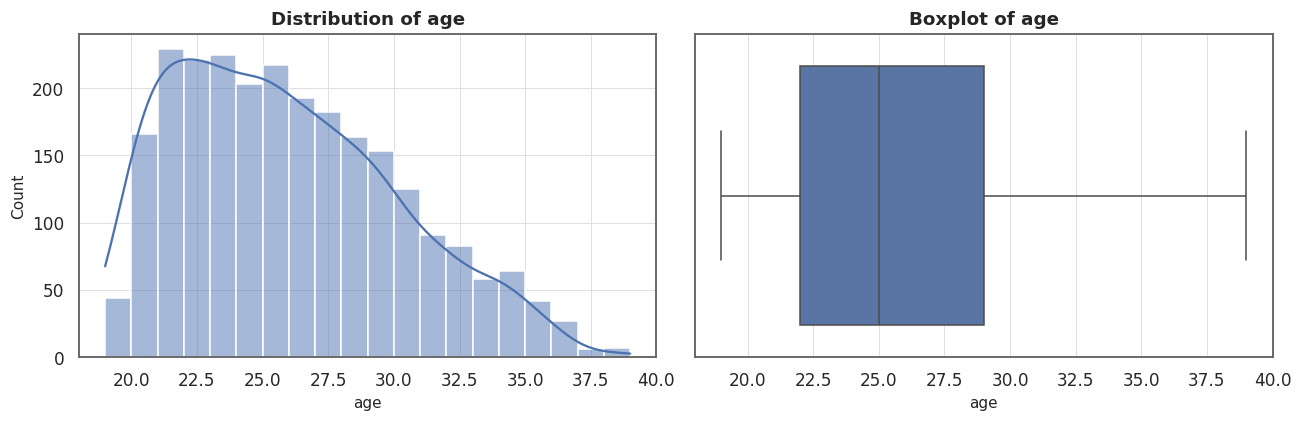

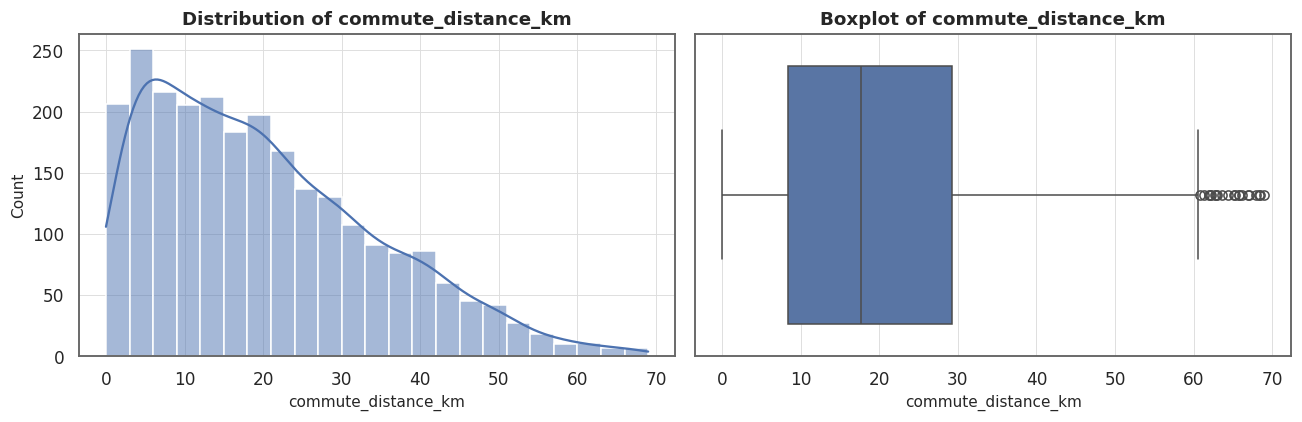

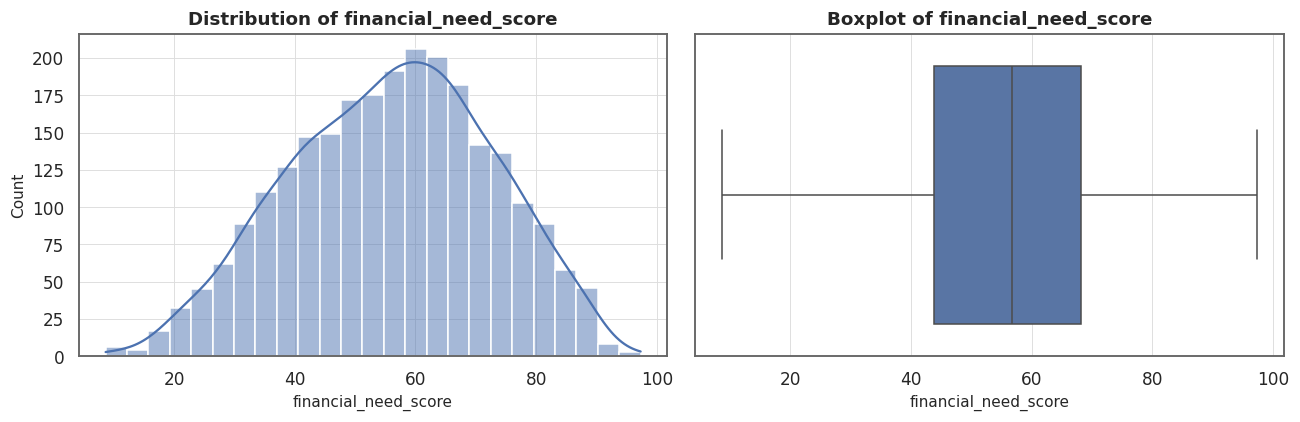

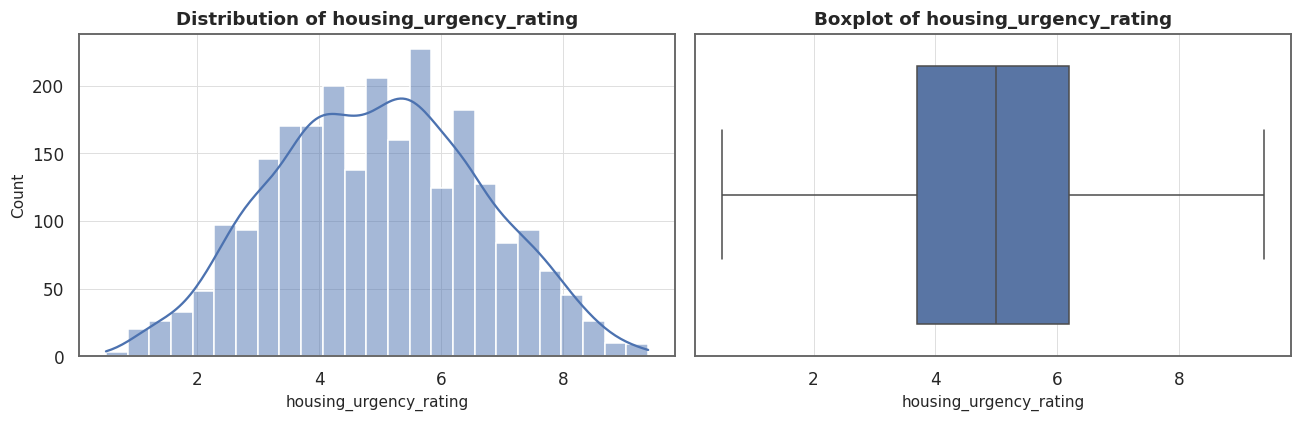

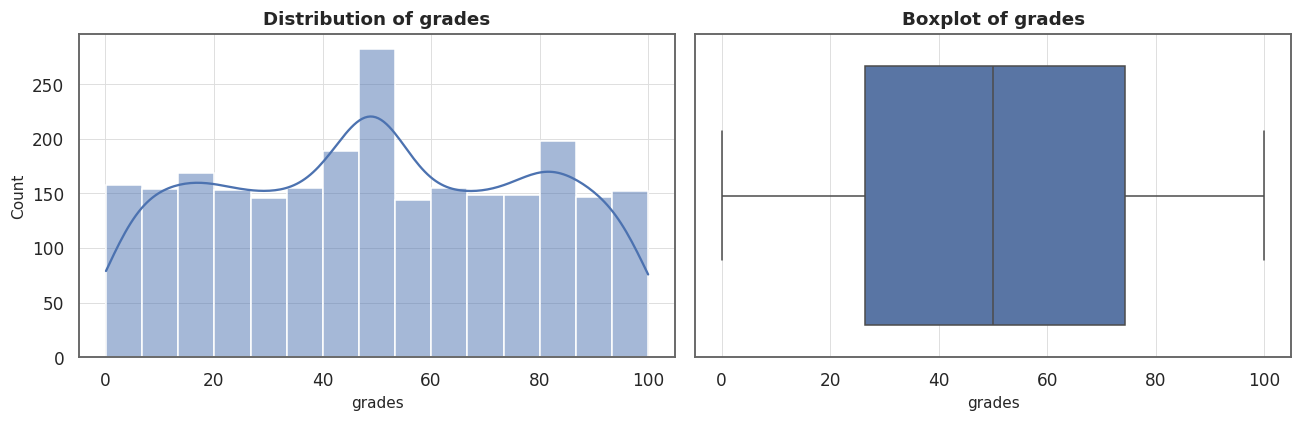

In [18]:
for col in numerical_features:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.histplot(data=house_df, x=col, kde=True, ax=axes[0])
    axes[0].set_title(f'Distribution of {col}')

    sns.boxplot(data=house_df, x=col, ax=axes[1])
    axes[1].set_title(f'Boxplot of {col}')

    plt.tight_layout()
    plt.show()

As the following plots show, we have heavy tails in age and commute_distance_km. Usually a machine learning
algorithm can learn better the majority, and the values in the majority area can be more effective on their
decisions.

Here, we know that age is one of our sensitive features. Due to having our interquartile range between 22 and 29,
it can affect the algorithms toward being more accurate for students in this range, and less accurate for the
older students in the tail.

About commute_distance_km, this tail could be good, because how far a student is should be effective to assign a
house to them or not. For this feature we can see many outliers too, but they are real distances and not errors,
so we keep them.

financial_need_score is close to a normal distribution centred around 57, and housing_urgency_rating is also
roughly symmetric around 5. These two look like scores that were designed to spread the applicants out, which fits
the idea that they are assessments made by the university and not raw facts about the student.

grades is flat by construction, because we replaced every value by its percentile inside its own recording
format. There is nothing to read in the shape of this one, the interesting part of grades was the recording
problem itself, which we already dealt with in the tidying part.

## 3.2 How do the groups compare?

Before the plots, it helps to have the plain numbers per group, since these are the same groups we will use in the
fairness sections.

In [19]:
group_summary = house_df.groupby('international')[
    ['age', 'semesters_completed', 'commute_distance_km', 'financial_need_score',
     'housing_urgency_rating', 'grades']
].mean().round(2)

group_summary['n'] = house_df.international.value_counts()
group_summary

,age,semesters_completed,commute_distance_km,financial_need_score,housing_urgency_rating,grades,n
international,,,,,,,
domestic,25.83,5.36,17.47,54.07,4.80,49.91,1907
international,25.71,5.26,28.73,62.30,5.43,50.56,593


In [20]:
age_summary = house_df.groupby('age_group')[
    ['semesters_completed', 'commute_distance_km', 'financial_need_score',
     'housing_urgency_rating', 'grades']
].mean().round(2)

age_summary['n'] = house_df.age_group.value_counts()
age_summary

,semesters_completed,commute_distance_km,financial_need_score,housing_urgency_rating,grades,n
age_group,,,,,,
25 or older,6.6,22.06,53.21,4.57,51.10,1412
under 25,3.7,17.65,59.67,5.44,48.72,1088


In [21]:
rates = pd.concat([
    house_df.groupby('international')[['should_recieve_housing'] + decision_columns].mean(),
    house_df.groupby('age_group')[['should_recieve_housing'] + decision_columns].mean(),
    house_df[['should_recieve_housing'] + decision_columns].mean().to_frame('overall').T
]).round(3)

rates

,should_recieve_housing,HO,A1,A2,A3,A4
domestic,0.311,0.336,0.205,0.310,0.260,0.223
international,0.476,0.479,0.457,0.680,0.395,0.383
25 or older,0.248,0.204,0.205,0.326,0.221,0.123
under 25,0.483,0.585,0.343,0.490,0.384,0.440
overall,0.350,0.370,0.265,0.398,0.292,0.261


A few things stand out here.

International students are only 593 out of 2500, so around 24 percent of the applicants. They live on average
about 11 km further from the university and they have a slightly higher financial need score and housing urgency
rating. Their base rate for the target is also higher, 48 percent against 31 percent for domestic students.

The age split is even sharper. Students under 25 have a target rate of 48 percent while students of 25 or older
have 25 percent. So age is not just a sensitive feature in principle, it is strongly connected to the target in
this dataset, and any decision method will inherit that connection.

We can also see that the decision methods do not select the same number of students. A2 allocates housing to
almost 40 percent of the applicants while A1 and A4 stay around 26 percent, and the target itself is 35 percent.
This alone will push precision and recall in different directions, which is useful to remember for the metrics
section.

The row for A2 already looks suspicious. It gives housing to 68 percent of the international applicants against 31
percent of the domestic ones, a gap far larger than the gap in the target itself (48 against 31). A4 goes the other
way on age, only 12 percent of the older group against 44 percent of the younger one. We will check both properly
in the fairness sections, but it is good to notice it here.

## 3.3 Categorical features: violin plots

Instead of plotting everything in one long loop, we look at one grouping variable at a time and comment on it,
because each row answers a different question.

In [22]:
def violin_row(group_col, continuous_cols=continuous_features, data=house_df, order=None):
    """Plot one row of violin plots: a grouping column against every continuous feature."""
    fig, axes = plt.subplots(1, len(continuous_cols), figsize=(5 * len(continuous_cols), 5))

    for ax, y_var in zip(np.atleast_1d(axes), continuous_cols):
        sns.violinplot(data=data, x=group_col, y=y_var, ax=ax, order=order)
        ax.set_title(f'{group_col} vs {y_var}')
        ax.set_xlabel(group_col)
        ax.set_ylabel(y_var)

    plt.tight_layout()
    plt.show()

### international vs the continuous features

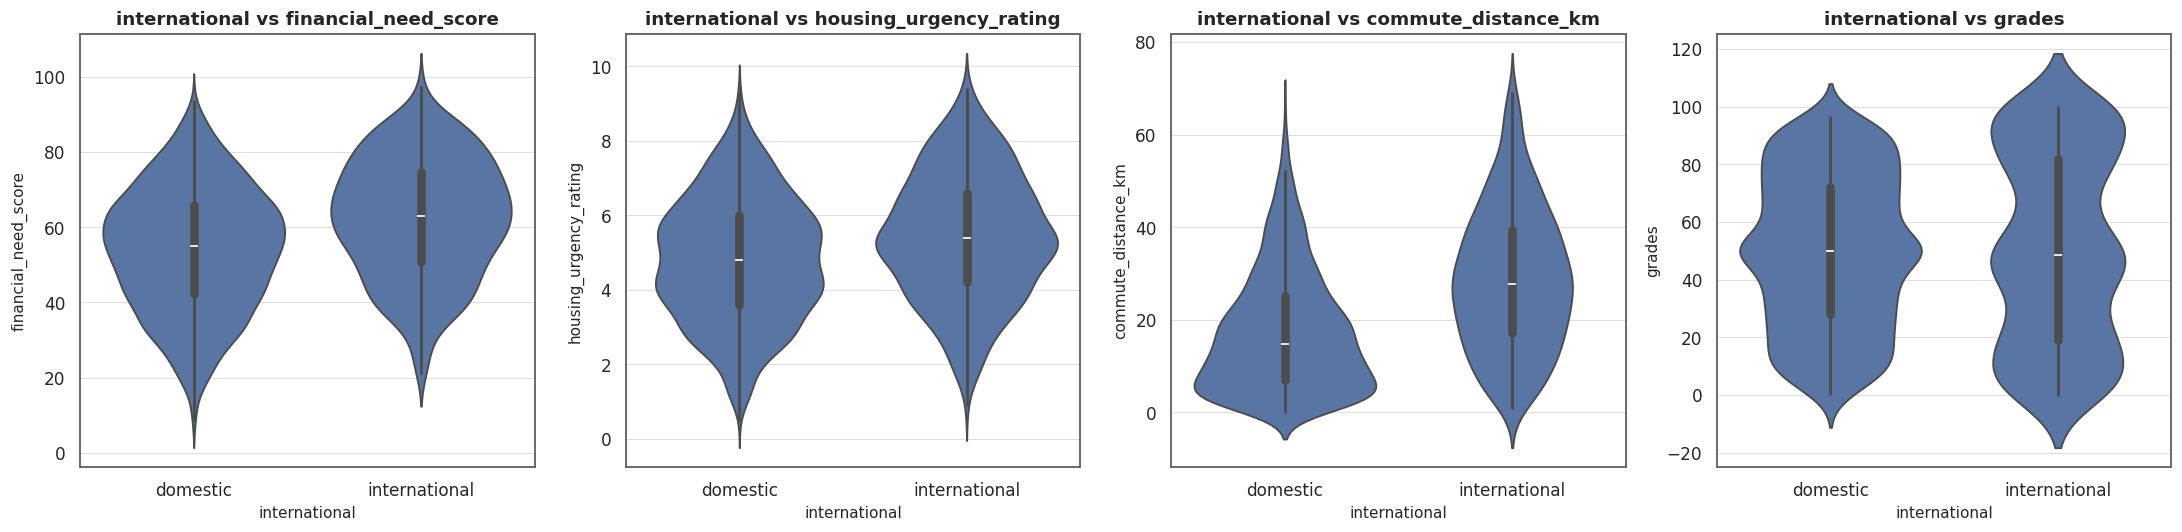

In [23]:
violin_row('international')

For me this part is very interesting.

As we can expect, being an international student can increase the need for financial aid. We can see that the
density around the higher financial need scores is bigger for international students than for domestic ones. The
same holds for housing urgency rating and, most clearly, for commute distance, which all make sense.

Grades are the interesting one for me, because of what is no longer there. The two violins are now the same
shape, with group means of 49.9 and 50.6. Before the percentile conversion the international side sat far above
the domestic side, but that gap was produced by the recording format and not by the students, and once every
student is ranked against the students recorded the same way it disappears completely.

### semesters_completed vs the continuous features

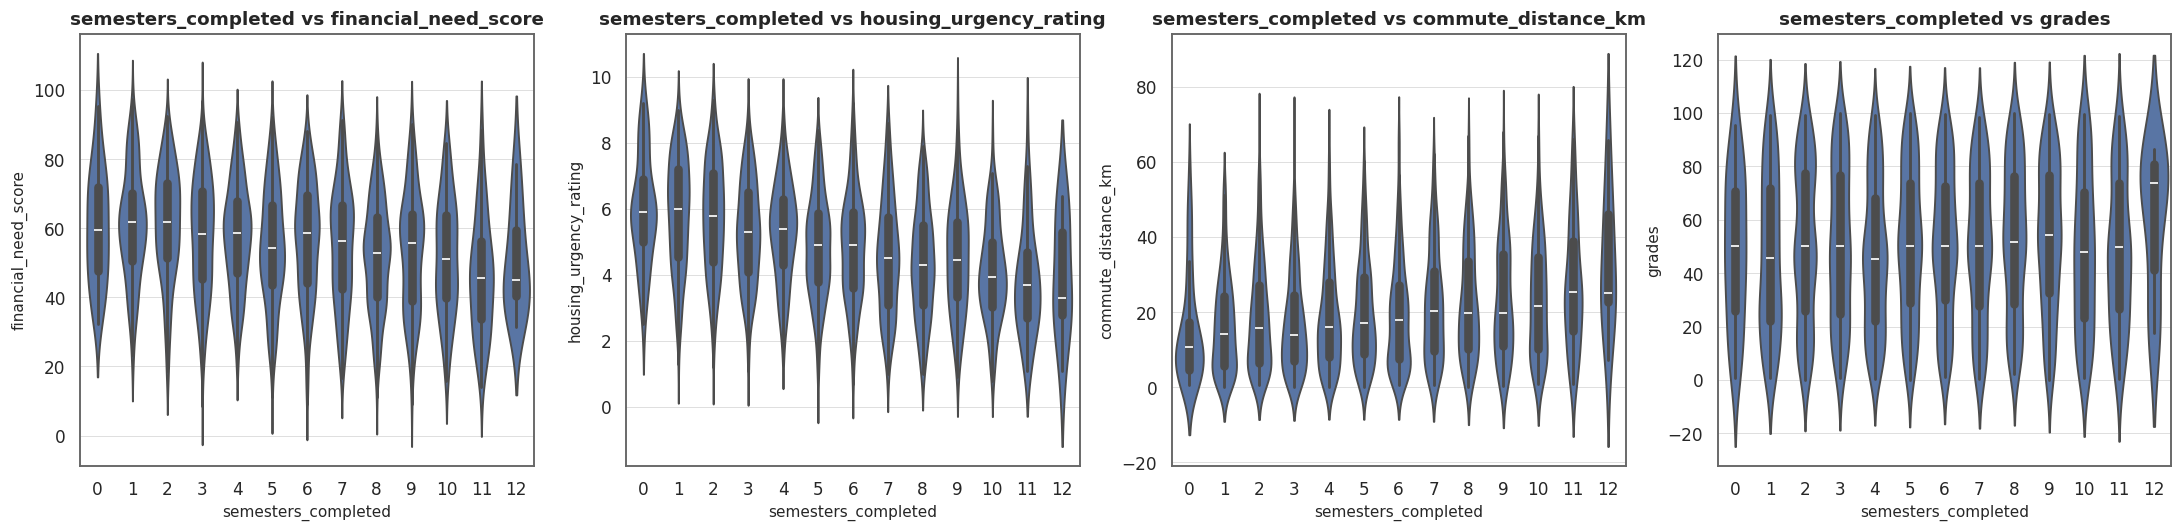

In [24]:
violin_row('semesters_completed')

Here we see a clear trend. The more semesters a student has completed, the lower the housing urgency rating and the
financial need score, and the longer the commute distance. Grades stay flat across all the semesters.

This makes sense in practice, a student who is further into their studies has probably already solved their housing
situation and moved somewhere, which is why they live further away and are considered less urgent. But it also
means that semesters_completed carries the same information as age, and we will confirm that with the correlation
in the next section.

### should_recieve_housing (our target) vs the continuous features

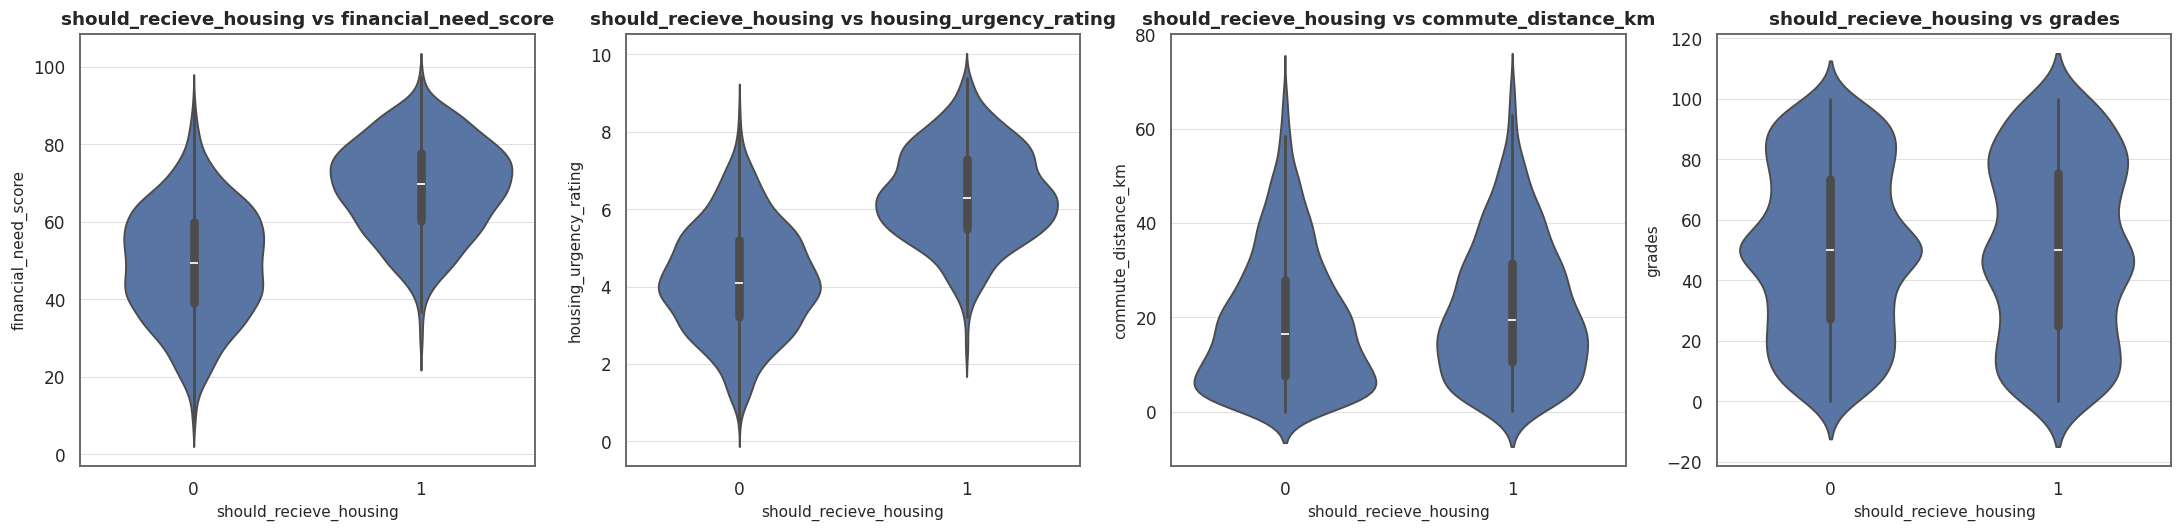

In [25]:
violin_row('should_recieve_housing')

This figure is important, because we are comparing the target with the continuous features.

The difference for financial_need_score and for housing_urgency_rating is large, which shows that students with a
higher financial need score and a higher housing urgency rating are much more likely to be marked as students who
should receive housing.

For commute_distance_km and grades the two shapes are almost identical. Higher commute distance has a slightly
higher density on the positive side, but it is not substantial, and grades show no difference at all, the group
means are 50.2 and 49.9. So the target is essentially built on two features only, need and urgency.

This is worth keeping for the fairness discussion. If the target only reflects two university-produced scores,
then whoever designed those two scores decided who deserves housing, and our accuracy numbers only measure
agreement with that decision.

### The decisions: HO and A1 to A4 vs the continuous features

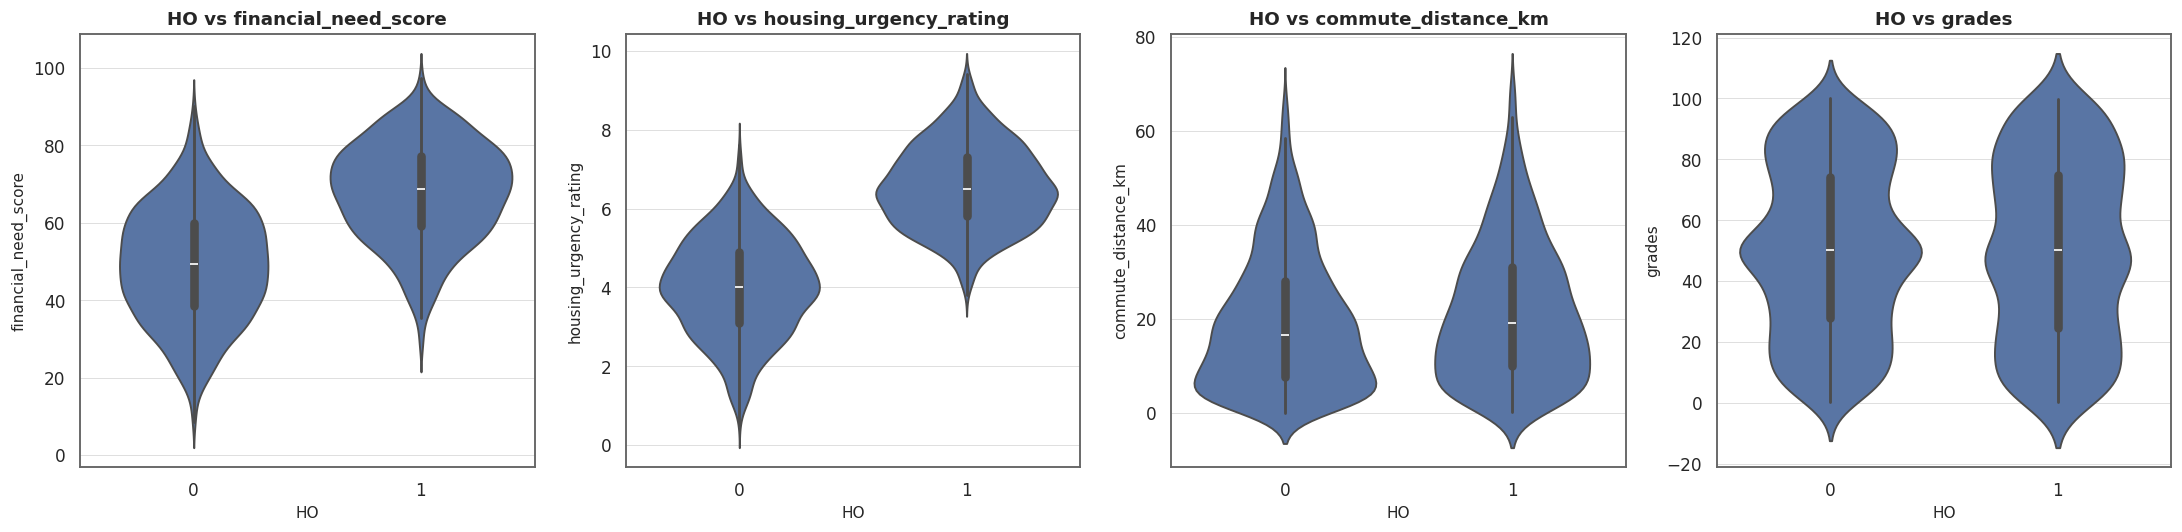

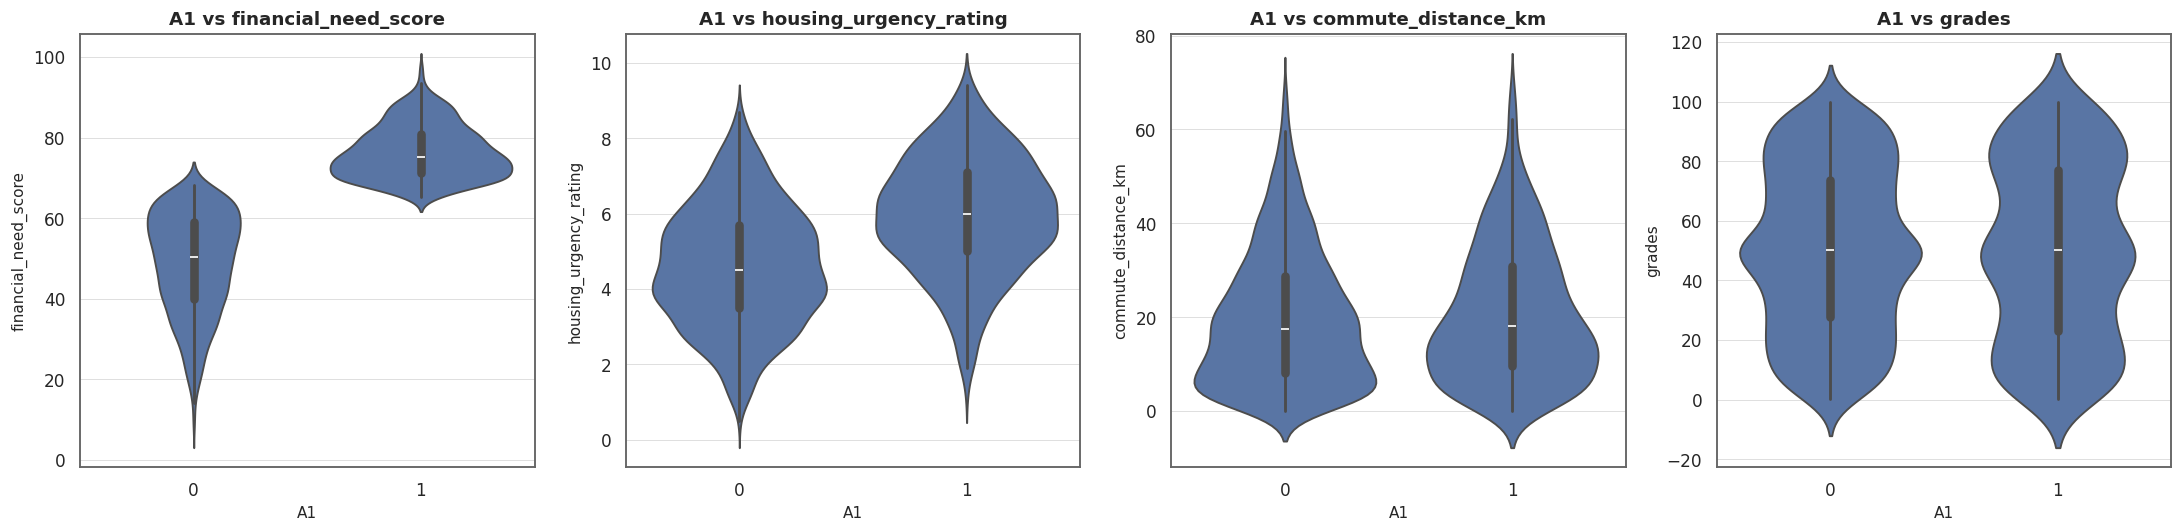

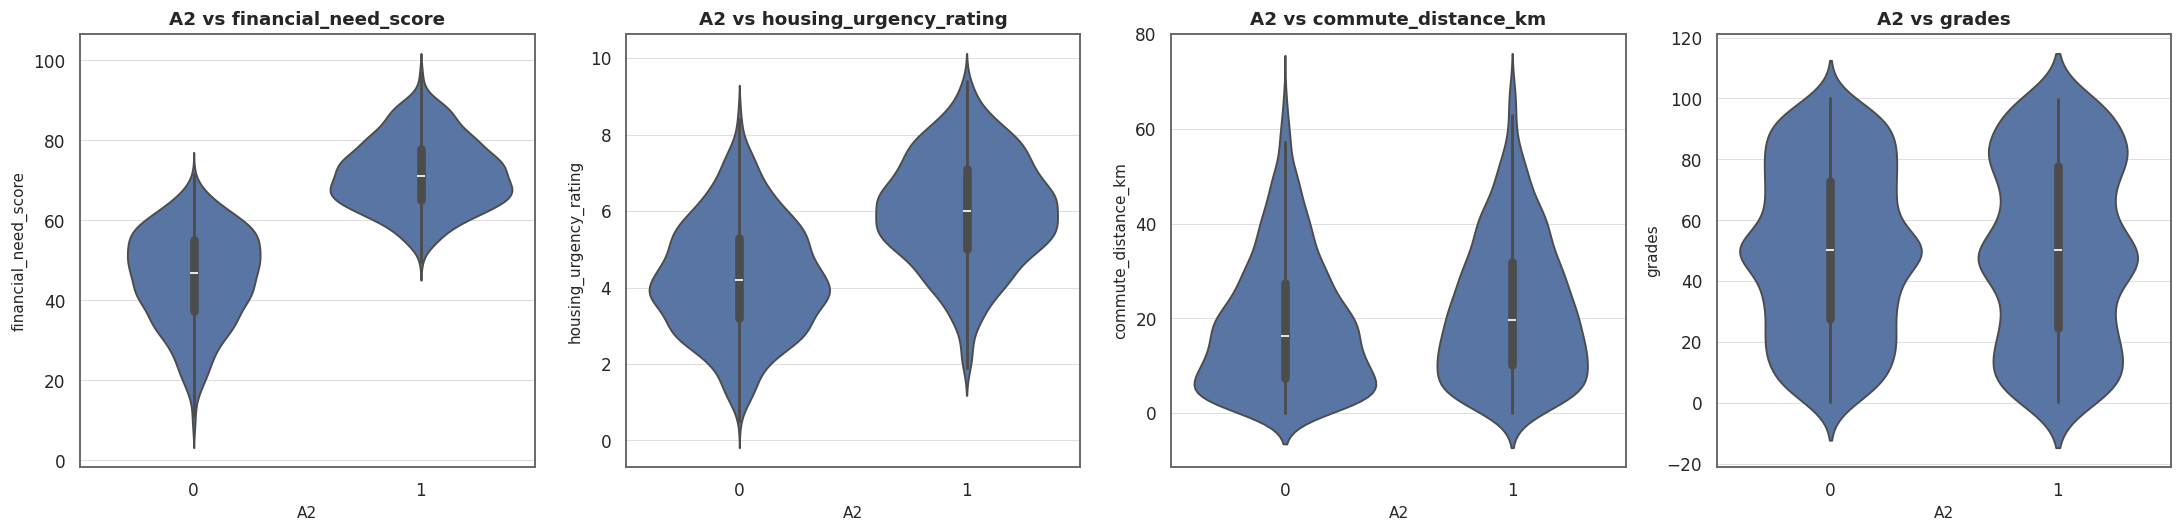

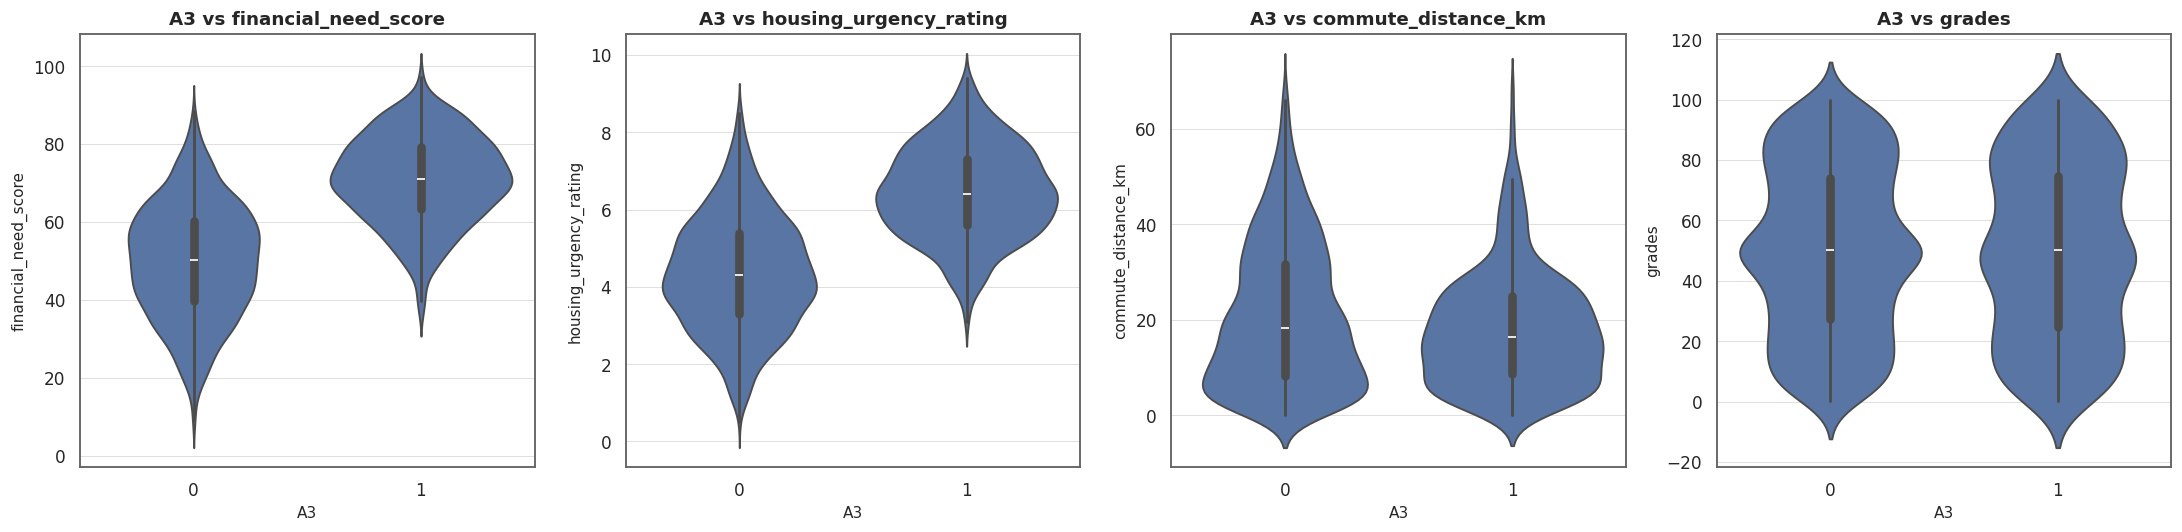

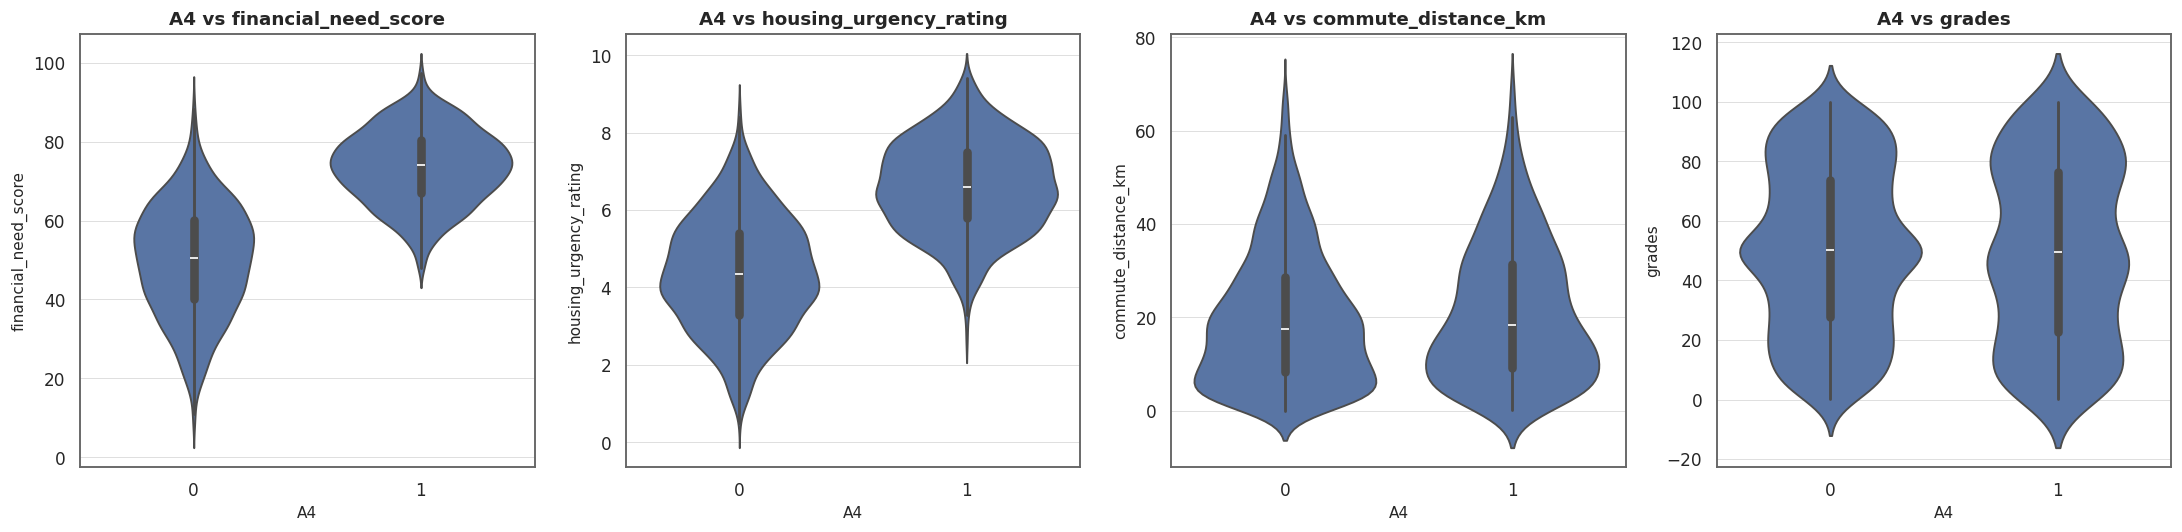

In [26]:
for col in decision_columns:
    violin_row(col)

HO stands for housing officer. Comparing these rows with the row of the target, the housing officer looks the most
similar to the target, which already suggests the officer will score well in the metrics section.

The difference between the officer and the algorithms is mostly in the balance between the two main features. The
officer separates the groups strongly on housing_urgency_rating, while A1 and A2 separate them mostly on
financial_need_score. For A1 the positive group is almost entirely above roughly 65 on financial need, and the
urgency violin barely moves, which looks like a decision based on a single feature with a threshold. A2 looks
similar but a bit softer, so probably financial need plus something else. A3 and A4 sit in between and use both
features, and A3 is the only one where the positive group has a slightly shorter commute distance than the
negative group.

Grades look identical between the two sides for every single decision method, so none of them seems to use grades
directly. That is good news given what we found about the grade formats.

## 4. How do features define each other?

#### We know in ml algorithms it is very important that the features explain the target well but do not define each other, to prevent multicollinearity.

### 4.1 Pearson correlation (continuous only)

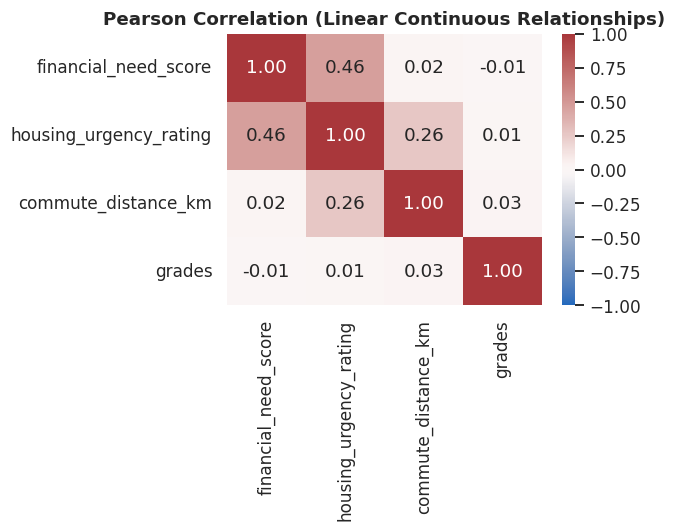

In [27]:
plt.figure(figsize=(6, 5))
pearson_corr = house_df[continuous_features].corr(method='pearson')
sns.heatmap(pearson_corr, annot=True, cmap=DIVERGING_CMAP, vmin=-1, vmax=1, fmt=".2f")
plt.title("Pearson Correlation (Linear Continuous Relationships)")
plt.tight_layout()
plt.show()

### There is no strong correlation between the continuous features. Just an average correlation between financial need score and housing urgency rating (0.46).

That one makes sense, a student with money problems is also likely to be in an urgent housing situation. It is
below the level where we would worry about multicollinearity, but it is high enough that the two features partly
say the same thing, so an algorithm using both is not really using two independent pieces of evidence.

### 4.2 Spearman correlation (ranked and continuous)

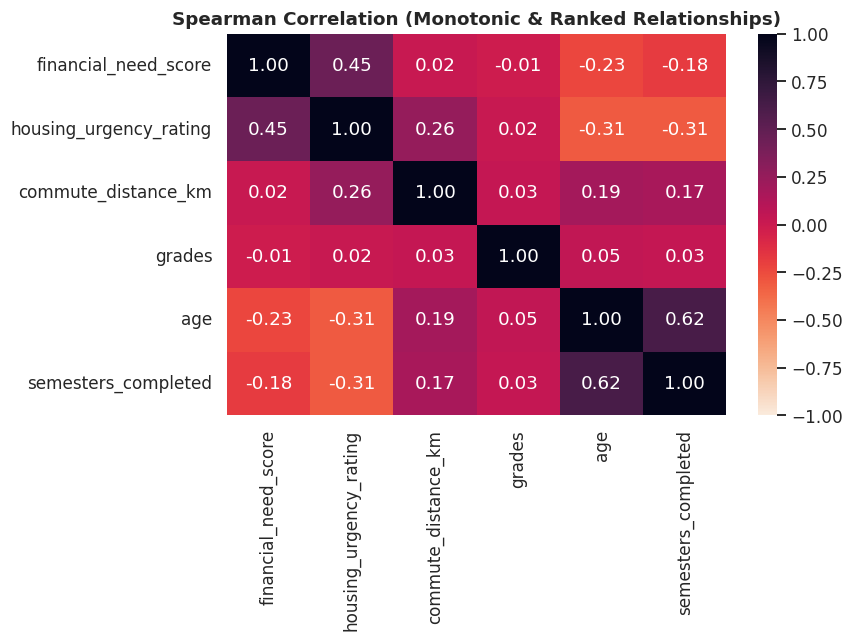

In [28]:
plt.figure(figsize=(8, 6))
spearman_features = continuous_features + ['age', 'semesters_completed']
spearman_corr = house_df[spearman_features].corr(method='spearman')
sns.heatmap(spearman_corr, annot=True, cmap=SEQUENTIAL_CMAP, vmin=-1, vmax=1, fmt=".2f")
plt.title("Spearman Correlation (Monotonic & Ranked Relationships)")
plt.tight_layout()
plt.show()

#### Here the previous results are confirmed again, with one difference, a higher correlation between semesters completed and age (0.62), which somehow makes sense :)

Two more things are worth pointing out. Age and semesters_completed both have a negative correlation with housing
urgency rating (-0.31) and with financial need score (-0.23 and -0.18). So older students and students further
into their studies are systematically considered less needy and less urgent by the university's own scores.

Since financial need and urgency are the two features that drive the target, this is the mechanism that makes age
predictive of the target without age appearing in the rule directly. In other words, even an algorithm that never
looks at age will still treat the age groups differently, which is exactly what we have to measure in the fairness
sections.

### 4.3 Point biserial correlation (binary vs continuous)

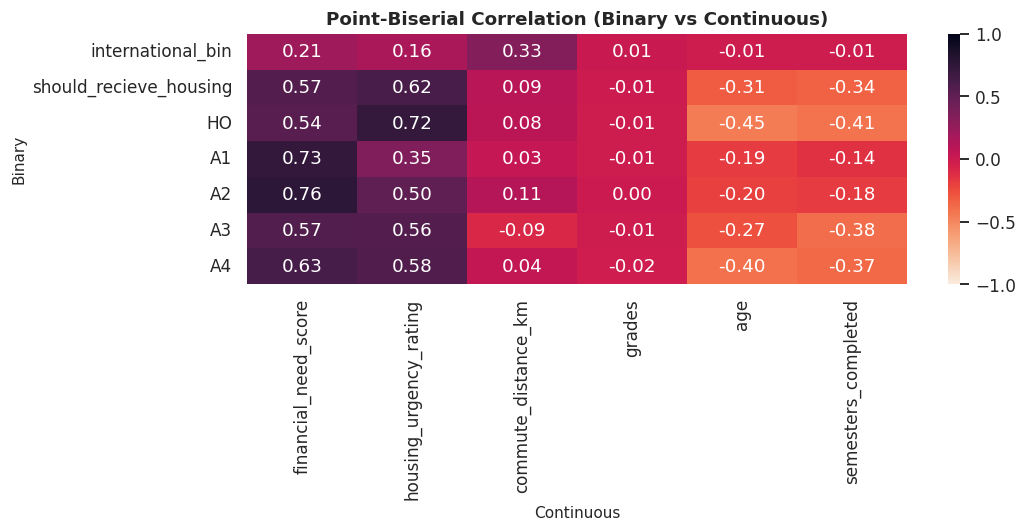

Continuous,financial_need_score,housing_urgency_rating,commute_distance_km,grades,age,semesters_completed
Binary,,,,,,
international_bin,0.211,0.156,0.333,0.010,-0.012,-0.015
should_recieve_housing,0.566,0.617,0.089,-0.005,-0.315,-0.337
HO,0.542,0.724,0.079,-0.011,-0.449,-0.410
A1,0.734,0.354,0.034,-0.011,-0.185,-0.137
A2,0.765,0.502,0.107,0.001,-0.202,-0.182
A3,0.571,0.564,-0.093,-0.014,-0.267,-0.384
A4,0.626,0.580,0.040,-0.020,-0.399,-0.368


In [29]:
binary_cols = ['international_bin', 'should_recieve_housing'] + decision_columns
against_cols = continuous_features + ['age', 'semesters_completed']

pb_results = []
for bin_col in binary_cols:
    for cont_col in against_cols:
        corr, p_val = stats.pointbiserialr(house_df[bin_col], house_df[cont_col])
        pb_results.append({'Binary': bin_col, 'Continuous': cont_col, 'Correlation': corr})

pb_df = (pd.DataFrame(pb_results)
           .pivot(index='Binary', columns='Continuous', values='Correlation')
           .reindex(index=binary_cols, columns=against_cols))

plt.figure(figsize=(10, 5))
sns.heatmap(pb_df, annot=True, cmap=SEQUENTIAL_CMAP, vmin=-1, vmax=1, fmt=".2f")
plt.title("Point-Biserial Correlation (Binary vs Continuous)")
plt.tight_layout()
plt.show()

pb_df.round(3)

This heatmap is the numerical version of the violin plots, and we added age and semesters_completed to it because
leaving them out would hide the most important relationship in the dataset.

Reading it row by row:

- The target correlates 0.57 with financial need and 0.62 with urgency, and only 0.03 with grades. Grades are
  irrelevant for the target.
- HO is the closest to the target on urgency (0.72) and is also the decision most negatively correlated with age
  (-0.45). The officer is harder on older applicants than the target itself is.
- A1 is dominated by financial need (0.73) with a much weaker link to urgency (0.35). A2 is similar (0.76 and
  0.50). A3 and A4 are more balanced, and A3 is the only decision with a negative correlation with commute
  distance (-0.09), which is strange because a longer commute should be an argument for getting housing and not
  against it.
- The international row now shows 0.01 with grades and 0.33 with commute distance. Commute distance still carries
  information about the sensitive attribute, grades no longer does. The `grade_format` column still does, which is
  why we keep it separate and never feed it to anything.
- No decision method has any correlation with grades, every one of them is under 0.02 in absolute value. So the
  algorithms do not use grades, and the officer does not either.

### 4.4 How much do the decision methods agree with each other?

The correlations tell us which features each method reacts to. It is also useful to see how often the methods
reach the same conclusion, because two methods can use different features and still produce similar decisions.

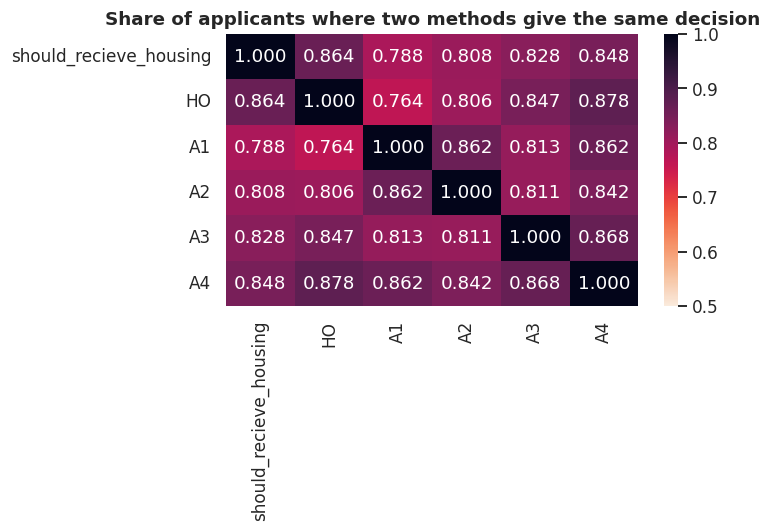

,should_recieve_housing,HO,A1,A2,A3,A4
should_recieve_housing,1.000,0.864,0.788,0.808,0.828,0.848
HO,0.864,1.000,0.764,0.806,0.847,0.878
A1,0.788,0.764,1.000,0.862,0.813,0.862
A2,0.808,0.806,0.862,1.000,0.811,0.842
A3,0.828,0.847,0.813,0.811,1.000,0.868
A4,0.848,0.878,0.862,0.842,0.868,1.000


In [30]:
all_decisions = ['should_recieve_housing'] + decision_columns

agreement = pd.DataFrame(
    {a: {b: (house_df[a] == house_df[b]).mean() for b in all_decisions} for a in all_decisions}
).loc[all_decisions, all_decisions]

plt.figure(figsize=(7, 5))
sns.heatmap(agreement, annot=True, cmap=SEQUENTIAL_CMAP, vmin=0.5, vmax=1, fmt=".3f")
plt.title("Share of applicants where two methods give the same decision")
plt.tight_layout()
plt.show()

agreement.round(3)

The housing officer agrees with the target on 86 percent of the applicants, which is the highest of all methods.
A4 comes second with 85 percent and A1 is last with 79 percent. Interestingly the algorithms agree with each other
roughly as much as they agree with the target, so they are not four independent opinions, they are four variations
of the same idea of ranking students by need and urgency.

These numbers are only a first look. In the metrics section we will split this into precision and recall, which
matters because the methods select very different numbers of students.

### 4.5 Variance Inflation Factor (VIF)

In [31]:
predictor_cols = continuous_features + ['age', 'semesters_completed']
X = house_df[predictor_cols]

X_with_const = add_constant(X)

vif_data = pd.DataFrame()
vif_data["Feature"] = X_with_const.columns
vif_data["VIF_Score"] = [variance_inflation_factor(X_with_const.values, i) for i in range(X_with_const.shape[1])]

vif_data = vif_data[vif_data["Feature"] != "const"].reset_index(drop=True)

print("\n--- Variance Inflation Factor (VIF) Scores ---")
print("Scores > 5 indicate high multicollinearity.")
print(vif_data.sort_values(by="VIF_Score", ascending=False).to_string(index=False))


--- Variance Inflation Factor (VIF) Scores ---
Scores > 5 indicate high multicollinearity.
               Feature  VIF_Score
                   age   1.758546
   semesters_completed   1.730230
housing_urgency_rating   1.592957
  financial_need_score   1.297990
   commute_distance_km   1.208040
                grades   1.003867


### As we can conclude, the VIF score for all of the continuous and ranked features is below 5, which is good news and shows we are not struggling with multicollinearity in our dataset.

The highest values belong to age and semesters_completed, which is expected after seeing their 0.62 correlation,
but they still stay in the safe range.